### Smirnov distribution sampling from logistic distribution

Smirnov sampling algorithm. Generate uniform random sample. 
Transform this sample with the quantile transformation of logistic distribution. 

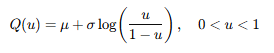

PDF:

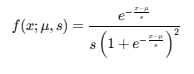

CDF: 

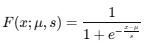

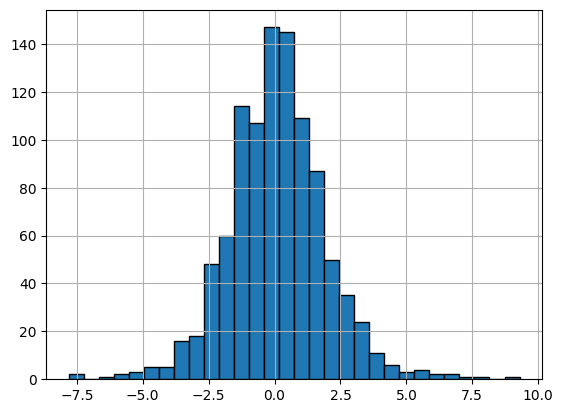

In [82]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

def cdf(x, mu, std):
    return 1/(1+np.exp(-(x-mu)/std))

def quantile_logistic(u, sigma, mean):
    return sigma*np.log((u/(1-u)))-mean

def uniform_sample(n, seed):
    us = []
    random.seed(seed)
    for _ in range(n):
        u = random.random()
        us.append(u)
    return np.array(us)

def generate_sample(n, seed=42):
    # Generates samples from logistic distribution
    us = uniform_sample(n, seed)
    xs = quantile_logistic(us, 1, 0)
    return xs

xs = generate_sample(1009)
plt.hist(xs, bins=30, edgecolor='black')
plt.grid()

# CDF Logistic regression

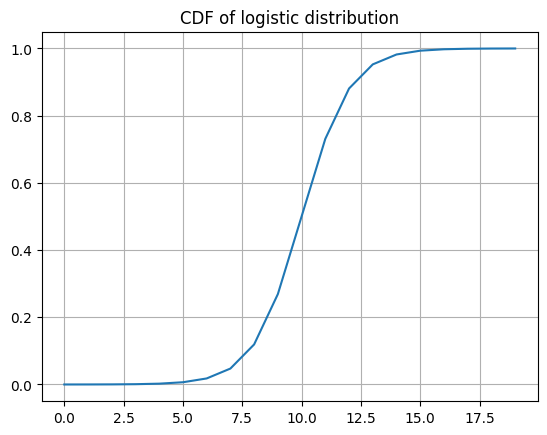

In [84]:
xs = np.arange(-10,10)
p = cdf(xs, 0, 1)
plt.title('CDF of logistic distribution')
plt.plot(p)
plt.grid()

# Maximum Likelihood optimization

#### Algorithm for solving logistic distribution MLE for finding parameters $\mu$, $\sigma$. 

log likelihood of logistic distribution:

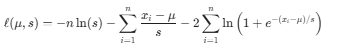


In general, we don't have analytical closed form solutions for population parameters, instead we need to find parameters numerically with some optimization algorithm. 

We use **coordinate ascent optimization algorithm** for finding the optimal parameters. Coordinate ascent works by fixing one parameter and searches the optimal value for another. A search for optimal parameters resembles grid like search trajectory to the optimum, as shown in the picture below:  



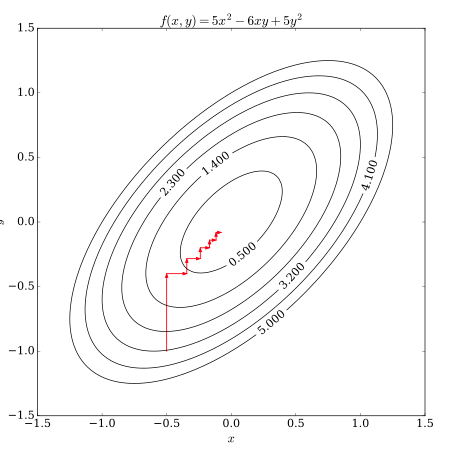

Search plan resembles the grid like motion to the optimum. Algorithm doesn't work so well on non-symetric functions. 



**Algorithm**:
- Generate sample from logistic distribution: $\{{x_i}\}_i$
- Guess the $\mu_{(0)}$ and find the $\sigma_{0}$ which maximizes the loglikelihood with fixed $\mu_{0}$
- Iterate until there is no improvement in $\mu_{(k)}$, $\sigma_{(k)}$

Optimization step is done by finding the root of the first order condition when one parameter is fixed and another varies. 







FOC sigma:

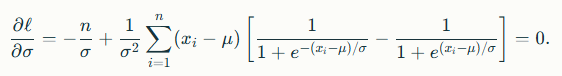

FOC mean:

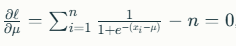

Hessian sigma: 

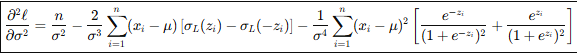

FOC mean: 

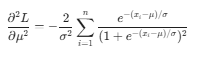

In [86]:
import numpy as np
from scipy.optimize import root_scalar

def root(f, range=[-10, 10]):
    try:
        sol = root_scalar(f, bracket=range, method='brentq')
    except ValueError as ve:
        print('ValueError: f(a) and f(b) must have different signs')
        return None
    return sol.root

def FOC_sigma(xs, mu, sigma):
    """
    Computes ∂ℓ/∂σ based on your handwritten formula.
    Formula: -n(mu - x_bar)/sigma^2 - n/sigma + 2 * sum( ((xi - mu)/sigma^2) * expit(-z) )
    """
    n = len(xs)
    x_bar = np.mean(xs)
    z = (xs - mu) / sigma
    
    # Term 1: -n(mu - x_bar) / sigma^2
    term1 = -n * (mu - x_bar) / (sigma**2)
    
    # Term 2: -n / sigma
    term2 = -n / sigma
    
    # Term 3: 2 * sum( ((xi - mu) / sigma^2) * [e^-z / (1 + e^-z)] )
    # We use expit(-z) to represent the exponential fraction safely.
    term3 = (2 / sigma**2) * np.sum((xs - mu) * expit(-z))
    
    return term1 + term2 + term3

def FOC_mu(xs, mu, sigma):
    """
    The FOC for mu. 
    """
    n = len(xs)
    z = (xs + mu) / sigma
    exp = np.exp(-z)/(1+np.exp(-z))
    return n/sigma - 2/sigma*np.sum(exp)


def der_FOC_sigma(xs, mu, sigma):
    """
    Computes df/dσ as:
    n/σ² − Σ[ 2(x_i−μ)/σ³ * tanh((x_i−μ)/(2σ))
             + (x_i−μ)²/(2σ⁴) * sech²((x_i−μ)/(2σ)) ]
    """
    x = np.asarray(xs)
    n = len(xs)
    z = (xs - mu) / (2 * sigma)
    tanh_term = np.tanh(z)
    sech2_term = 1 / np.cosh(z)**2  # sech²(z)
    sum_term = (
        2 * (xs - mu) / sigma**3 * tanh_term
        + (xs - mu)**2 / (2 * sigma**4) * sech2_term
    )
    return n / sigma**2 - np.sum(sum_term)

def der_FOC_mean(xs, mu, sigma):
    first = np.exp(mu-xs)
    second = (1+np.exp(mu-xs))**2
    return first/second


######################################


def optimum_sigma(xs, mu, epsilon=0.001, max_iter=1000):
    mu = np.random.uniform(0, 10)
    F = FOC_sigma(xs, mu, sigma)
    if F > 0:
        oper = lambda a, b: a+b
    else:
        oper = lambda a, b: a-b
    mu_list    = []
    sigma_list = []
    for _ in range(max_iter):
        F = FOC_sigma(xs, mu, sigma)
        if F < epsilon:
            return sigma_list[-1]
        delta_mu = der_FOC_mean(xs, mu, sigma) * epsilon
        delta_sigma = der_FOC_sigma(xs, mu, sigma) * epsilon
        mu = oper(mu, delta_mu) # mu = mu + delta_mu
        sigma = oper(sigma, delta_sigma) # sigma = sigma + delta_sigma
        mu_list.append(mu)
        sigma_list.append(sigma)
    return mu_list[-1], sigma_list[-1]

def optimum_mu(xs, sigma, epsilon=0.001, max_iter=1000):
    pass


def find_optimum(xs, epsilon=0.001):
    """ Finds the optimum values of the sigma and mu"""
    mu = xs.mean()
    while True:
        sigma1 = optimum_sigma(xs, mu)
        mu1 = optimum_mu(xs, sigma1)
        sigma = optimum_sigma(xs, mu1)
        mu = optimum_mu(xs, mu)
        if abs(mu1 - mu) <= epsilon and abs(sigma1 - sigma) <= epsilon:
            return mu, sigma


xs = generate_sample(100)
# FOC_mean(xs, 1, 4)

#find_optimum(xs)


In [95]:
def optimum_sigma(xs, mu, epsilon=0.001, max_iter=1000):
    sigma = np.random.uniform(0, 10)
    F = FOC_sigma(xs, mu, sigma)
    if F > 0:
        oper = lambda a, b: a+b
    else:
        oper = lambda a, b: a-b
    mu_list    = []
    sigma_list = []
    for _ in range(max_iter):
        F = FOC_sigma(xs, mu, sigma)
        if F < epsilon:
            return sigma_list[-1]
        delta_mu = der_FOC_mean(xs, mu, sigma) * epsilon
        delta_sigma = der_FOC_sigma(xs, mu, sigma) * epsilon
        mu = oper(mu, delta_mu) # mu = mu + delta_mu
        sigma = oper(sigma, delta_sigma) # sigma = sigma + delta_sigma
        mu_list.append(mu)
        sigma_list.append(sigma)
    return mu_list[-1], sigma_list[-1]

### Visualize the one variable coordinate root finding. 

Root is the the solution to the FOC and it is a coordinate maximum. 

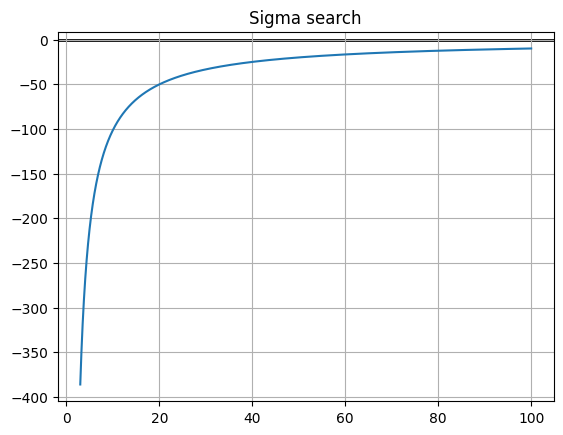

In [90]:
def L_sigma_HOF(xs, mu):
    return lambda sigma : FOC_sigma(xs, mu, sigma)

def L_mu_HOF(xs, sigma):
    return lambda mu : FOC_mu(xs, mu, sigma)

#Plot the search in sigma space
xs = generate_sample(1000, seed=2)
mu = xs.mean()
L_sigma = L_sigma_HOF(xs, mu)
sigmas = np.arange(3, 100, 0.01)
likelihood_sigmas_1d = [L_sigma(s) for s in sigmas]
plt.plot(sigmas, likelihood_sigmas_1d)
plt.grid()
plt.title('Sigma search')
plt.axhline(0, color='black', linewidth=2, zorder=1)




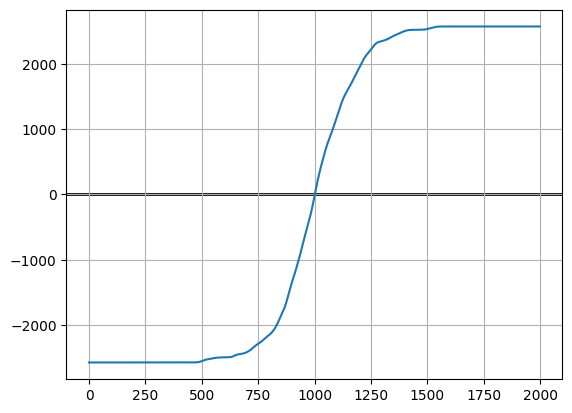

In [91]:
#Plot the search in mu space
xs = generate_sample(200, seed=30)
mu = xs.mean()
L_mu = L_mu_HOF(xs, mu)
mus = np.arange(-10, 10, 0.01)
likelihood_sigmas_1d = [L_mu(m) for m in mus]
plt.plot(likelihood_sigmas_1d)
plt.grid()
plt.axhline(0, color='black', linewidth=2, zorder=1)